### Credit Card Fraud Detection


This notebook aims to demonstrate credit card fraud detection using various machine learning models. We will go through the steps of data loading, preprocessing, model training, evaluation, and comparison.

Dataset Link: [Credit Card](https://drive.google.com/file/d/1lV7Xk3nQ66RCVbdsJXXcO5duc38z501K/view?usp=drive_link)

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import time

In [2]:
# Step 1: Read the dataset
df = pd.read_csv('creditcard.csv')
print(df.head(50))

    Time        V1        V2        V3        V4        V5        V6  \
0    0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388   
1    0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361   
2    1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499   
3    1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203   
4    2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921   
5    2.0 -0.425966  0.960523  1.141109 -0.168252  0.420987 -0.029728   
6    4.0  1.229658  0.141004  0.045371  1.202613  0.191881  0.272708   
7    7.0 -0.644269  1.417964  1.074380 -0.492199  0.948934  0.428118   
8    7.0 -0.894286  0.286157 -0.113192 -0.271526  2.669599  3.721818   
9    9.0 -0.338262  1.119593  1.044367 -0.222187  0.499361 -0.246761   
10  10.0  1.449044 -1.176339  0.913860 -1.375667 -1.971383 -0.629152   
11  10.0  0.384978  0.616109 -0.874300 -0.094019  2.924584  3.317027   
12  10.0  1.249999 -1.221637  0.383930 -1.234899 -1.485419 -0.75

In [3]:
# Take features and target
target = 'Class'
features = df.columns.tolist()
features.remove(target)
X = df[features]
y = df[target]

In [4]:
# Step 2: Undersampling the non-fraud to match the fraud
# 50% fraud and 50% Non-Fraud -> sampling_strategy = 5/5 = 1
# 100% Balance between classes
rus = RandomUnderSampler(sampling_strategy=1.0, random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)
# New dataset
df_resampled = pd.DataFrame(data=X_resampled, columns=features)
df_resampled[target] = y_resampled

In [5]:
# Step 3: 70% Training / 15% Validation / 15% Testing Data
train_df, val_test_df = train_test_split(df_resampled, test_size=0.3, random_state=42)
eval_df, test_df = train_test_split(val_test_df, test_size=0.5, random_state=42)

In [6]:
# Separate the features
X_train, y_train = train_df[features], train_df[target]
X_eval, y_eval = eval_df[features], eval_df[target]
X_test, y_test = test_df[features], test_df[target]

In [7]:
# Step 4: Standardize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_eval_scaled = scaler.transform(X_eval)
X_test_scaled = scaler.transform(X_test)

In [8]:
# Step 5: Define a function to train a model using ML techniques
def train_evaluate_model(model, name):
    print("Model Used:", name)
    start_train = time.time()

    model.fit(X_train_scaled, y_train)

    end_train = time.time()

    print(f"Training Complete! Training Time: {end_train - start_train}")

    # Use Validation Data -> Mock Test
    start_eval = time.time()

    y_pred = model.predict(X_eval_scaled)
    conf_matrix_eval = confusion_matrix(y_eval, y_pred)
    accuracy_eval = accuracy_score(y_eval, y_pred)
    precision_eval = precision_score(y_eval, y_pred)
    recall_eval = recall_score(y_eval, y_pred)
    f1score_eval = f1_score(y_eval, y_pred)

    end_eval = time.time()

    print(f"Validation Complete! Validation Time: {end_eval - start_eval}")
    print(f"Confusion Matrix:\n {conf_matrix_eval}\nAccuracy: {accuracy_eval} "
          f"\nPrecision: {precision_eval} \nRecall {recall_eval} \nF1-Score {f1score_eval}")

    # Testing model
    start_test = time.time()

    y_pred = model.predict(X_test_scaled)
    conf_matrix = confusion_matrix(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1score = f1_score(y_test, y_pred)

    end_test = time.time()

    print(f"Testing Complete! Testing Time: {end_test - start_test}")
    print(f"Confusion Matrix:\n {conf_matrix}\nAccuracy: {accuracy} "
          f"\nPrecision: {precision} \nRecall {recall} \nF1-Score {f1score}")

    # Return a dictionary
    return {"Model": name, "Accuracy": accuracy, "Precision": precision,
            "Recall": recall, "F1-Score": f1score}

In [9]:
def make_prediction(model):  # Predict the first 10 samples
    sample = X_test_scaled[:10]
    actual = y_test[:10]
    predicted = model.predict(sample)
    print("Predicted Labels:", predicted)
    print("True Labels:", actual.values)

In [10]:
# Function to visualize model comparison
def plot_metrics(results):
    df_results = pd.DataFrame(results)
    df_results.set_index('Model', inplace=True)

    # Plot each metric in a grouped bar chart
    df_results.plot(kind='bar', figsize=(12, 6))
    plt.title('Model Performance Comparison')
    plt.ylabel('Score')
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(rotation=0)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

Model Used: KNN
Training Complete! Training Time: 0.004591941833496094
Validation Complete! Validation Time: 0.23220396041870117
Confusion Matrix:
 [[73  2]
 [ 8 65]]
Accuracy: 0.9324324324324325 
Precision: 0.9701492537313433 
Recall 0.8904109589041096 
F1-Score 0.9285714285714286
Testing Complete! Testing Time: 0.006838083267211914
Confusion Matrix:
 [[74  1]
 [13 60]]
Accuracy: 0.9054054054054054 
Precision: 0.9836065573770492 
Recall 0.821917808219178 
F1-Score 0.8955223880597015
Predicted Labels: [1 1 0 1 1 1 1 1 0 1]
True Labels: [1 1 0 1 1 1 1 1 0 1]
Model Used: Decision Tree
Training Complete! Training Time: 0.011202096939086914
Validation Complete! Validation Time: 0.005290985107421875
Confusion Matrix:
 [[69  6]
 [ 8 65]]
Accuracy: 0.9054054054054054 
Precision: 0.9154929577464789 
Recall 0.8904109589041096 
F1-Score 0.9027777777777778
Testing Complete! Testing Time: 0.005007266998291016
Confusion Matrix:
 [[67  8]
 [12 61]]
Accuracy: 0.8648648648648649 
Precision: 0.88405797

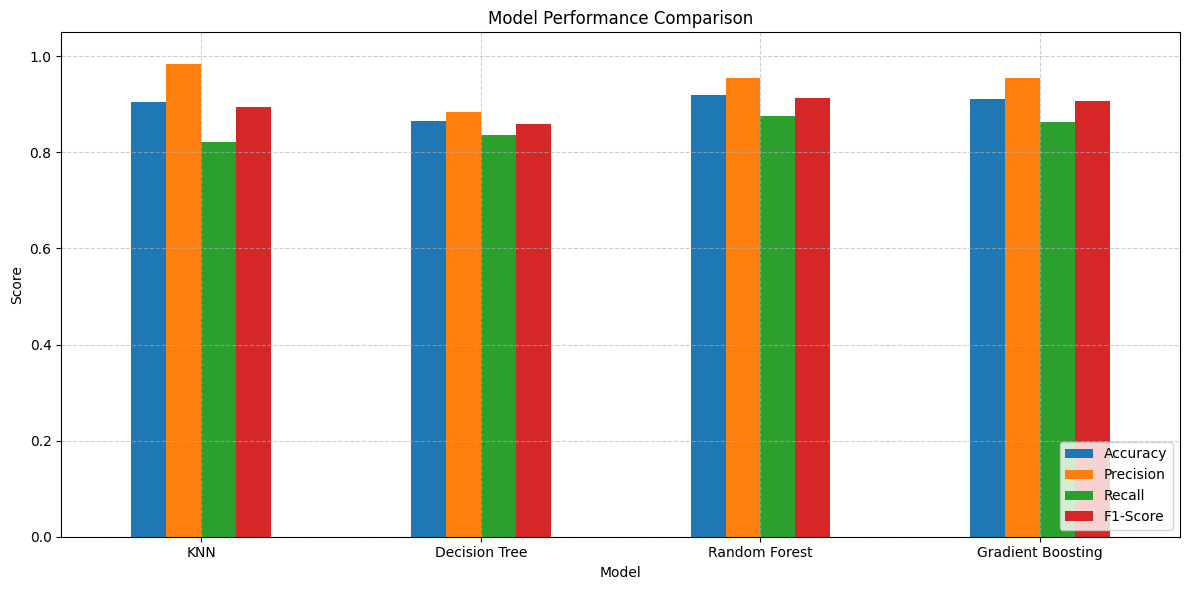

In [11]:
# Step 6: Train, evaluate, and compare models
models = {KNeighborsClassifier(n_neighbors=10): "KNN",
         DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42): "Decision Tree",
         RandomForestClassifier(n_estimators=100, random_state=42): "Random Forest",
         GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5,
                                    random_state=42): "Gradient Boosting"}
results = []
for model, name in models.items():
    res = train_evaluate_model(model, name)
    results.append(res)
    make_prediction(model)

plot_metrics(results)